# Raincloud Plots — Comparación de Modelos
Lee `Comparacion_Modelos_De pie.csv` y genera raincloud plots por movimiento.
Cada figura tiene 3 subplots (ROM / Máximo / Mínimo), y en cada subplot
aparecen 3 series por lado (Complete · C7 · NOT_C7).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from scipy.stats import gaussian_kde
import pandas as pd
from pathlib import Path

In [2]:
# ── Condición ─────────────────────────────────────────────────────────────
# Cambiar entre "De pie" y "Sentado" para cargar el archivo correspondiente
CONDITION = "De pie"

BASE_DIR = Path(r"C:\Projects\Scripts_results_analysis_plots\Intermodel comparison\Mean_SD_comparison")
DPI = 150

## 1. Parser del CSV

In [3]:
def _rows_to_sections(rows: list) -> dict:
    """
    Convierte una lista de filas (list of lists) al dict {movement: DataFrame}.
    Comparte lógica entre CSV y XLSX.
    """
    sections = {}
    current_name = None
    current_rows = []
    current_header = None

    def flush():
        nonlocal current_name, current_rows, current_header
        if current_name and current_rows:
            df = pd.DataFrame(current_rows, columns=current_header, dtype=object)
            new_cols = []
            for i in range(df.shape[1]):
                series = df.iloc[:, i]
                converted = pd.to_numeric(series, errors="coerce")
                new_cols.append(converted if converted.notna().any() else series)
            df = pd.concat(new_cols, axis=1)
            df.columns = current_header
            sections[current_name] = df
        current_rows = []
        current_header = None

    for raw_cols in rows:
        cols = [str(c).strip() if c not in (None, "nan") else "" for c in raw_cols]
        while cols and cols[-1] == "":
            cols.pop()

        if not cols or all(c == "" for c in cols):
            continue

        if cols[0] not in ("Model", "") and (len(cols) == 1 or cols[1] == ""):
            flush()
            current_name = cols[0]
            continue

        if cols[0] == "Model":
            current_header = cols
            continue

        if current_header and cols[0] in ("Complete", "C7", "NOT_C7"):
            row = cols + [""] * (len(current_header) - len(cols))
            current_rows.append(row[:len(current_header)])

    flush()
    return sections


def parse_csv(path: Path) -> dict:
    with open(path, encoding="utf-8-sig") as f:
        rows = [[c.strip() for c in line.rstrip("\n").split(";")] for line in f]
    return _rows_to_sections(rows)


def parse_xlsx(path: Path) -> dict:
    raw = pd.read_excel(path, header=None, dtype=str, sheet_name=0)
    rows = raw.fillna("").values.tolist()
    return _rows_to_sections(rows)


def load_sections(condition: str) -> dict:
    if condition == "De pie":
        return parse_csv(BASE_DIR / "Comparacion_Modelos_De pie.csv")
    elif condition == "Sentado":
        return parse_xlsx(BASE_DIR / "Comparacion_Modelos_Sentado.xlsx")
    else:
        raise ValueError(f"Condición desconocida: {condition!r}. Usar 'De pie' o 'Sentado'.")


sections = load_sections(CONDITION)
print(f"Condición: {CONDITION!r}")
print("Secciones encontradas:")
for name, df in sections.items():
    print(f"  {name!r}: {len(df)} filas, columnas: {list(df.columns)}")

Condición: 'De pie'
Secciones encontradas:
  'Shoulder Flex/Ext (Unilateral)': 21 filas, columnas: ['Model', 'Rep', 'Left Peak Frame', 'Left Peak Time (s)', 'Left Peak (°)', 'Left Valley Frame', 'Left Valley Time (s)', 'Left Valley (°)', 'ROM (°)', 'Right Peak Frame', 'Right Peak Time (s)', 'Right Peak (°)', 'Right Valley Frame', 'Right Valley Time (s)', 'Right Valley (°)', 'ROM (°)']
  'Shoulder Abd/Add (Unilateral)': 18 filas, columnas: ['Model', 'Rep', 'Left Peak Frame', 'Left Peak Time (s)', 'Left Peak (°)', 'Left Valley Frame', 'Left Valley Time (s)', 'Left Valley (°)', 'ROM (°)', 'Right Peak Frame', 'Right Peak Time (s)', 'Right Peak (°)', 'Right Valley Frame', 'Right Valley Time (s)', 'Right Valley (°)', 'ROM (°)']
  'Shoulder Int/Ext Rot (Unilateral)': 18 filas, columnas: ['Model', 'Rep', 'Left Peak Frame', 'Left Peak Time (s)', 'Left Peak (°)', 'Left Valley Frame', 'Left Valley Time (s)', 'Left Valley (°)', 'ROM (°)', 'Right Peak Frame', 'Right Peak Time (s)', 'Right Peak (°)'

## 2. Extracción de valores por modelo y lado

In [4]:
MODELS = ["Complete", "C7", "NOT_C7"]


def extract_data(df: pd.DataFrame) -> dict:
    """
    Detecta si el movimiento es Unilateral o Bilateral
    y extrae {model: {side: {metric: [values]}}}.

    Para Unilateral:
        sides = ["Left", "Right"]
        Left  → cols: 'Left Peak (°)', 'Left Valley (°)', 'ROM (°)' (primera aparición)
        Right → cols: 'Right Peak (°)', 'Right Valley (°)', 'ROM (°)' (segunda aparición)
    Para Bilateral:
        sides = ["Left"]
        Left  → cols: 'Left Peak (°)', 'Left Valley (°)', 'ROM (°)'
    """
    cols = list(df.columns)
    bilateral = "Right Peak (°)" not in cols

    # Encontrar los índices de 'ROM (°)' (puede aparecer dos veces en unilateral)
    rom_indices = [i for i, c in enumerate(cols) if c == "ROM (°)"]

    result = {}
    for model in MODELS:
        sub = df[df["Model"] == model]
        if sub.empty:
            continue

        model_data = {}

        # Lado Left
        left = {}
        left["peak"]   = sub["Left Peak (°)"].dropna().astype(float).tolist()
        left["valley"] = sub["Left Valley (°)"].dropna().astype(float).tolist()
        if rom_indices:
            left["rom"] = sub.iloc[:, rom_indices[0]].dropna().astype(float).tolist()
        model_data["Left"] = left

        if not bilateral and "Right Peak (°)" in cols:
            right = {}
            right["peak"]   = sub["Right Peak (°)"].dropna().astype(float).tolist()
            right["valley"] = sub["Right Valley (°)"].dropna().astype(float).tolist()
            if len(rom_indices) > 1:
                right["rom"] = sub.iloc[:, rom_indices[1]].dropna().astype(float).tolist()
            elif rom_indices:
                # Intentar columna 'ROM (°).1' si pandas la renombró
                rom2_candidates = [c for c in cols if "ROM" in c and c != "ROM (°)"]
                if rom2_candidates:
                    right["rom"] = sub[rom2_candidates[0]].dropna().astype(float).tolist()
                else:
                    right["rom"] = []
            model_data["Right"] = right

        result[model] = model_data

    return result


# Prueba rápida con la primera sección
first_name = list(sections.keys())[0]
first_data = extract_data(sections[first_name])
print(f"\n{first_name!r}:")
for model, sides in first_data.items():
    for side, metrics in sides.items():
        for metric, vals in metrics.items():
            print(f"  {model:10s} {side:6s} {metric:7s}: n={len(vals)}  "
                  f"mean={np.mean(vals):.2f}°")


'Shoulder Flex/Ext (Unilateral)':
  Complete   Left   peak   : n=7  mean=154.79°
  Complete   Left   valley : n=7  mean=-45.50°
  Complete   Left   rom    : n=7  mean=200.28°
  Complete   Right  peak   : n=7  mean=159.70°
  Complete   Right  valley : n=7  mean=-43.60°
  Complete   Right  rom    : n=7  mean=203.29°
  C7         Left   peak   : n=7  mean=153.74°
  C7         Left   valley : n=7  mean=-46.25°
  C7         Left   rom    : n=7  mean=200.00°
  C7         Right  peak   : n=7  mean=157.59°
  C7         Right  valley : n=7  mean=-43.23°
  C7         Right  rom    : n=7  mean=200.82°
  NOT_C7     Left   peak   : n=7  mean=157.45°
  NOT_C7     Left   valley : n=7  mean=-49.71°
  NOT_C7     Left   rom    : n=7  mean=207.16°
  NOT_C7     Right  peak   : n=7  mean=161.64°
  NOT_C7     Right  valley : n=7  mean=-45.41°
  NOT_C7     Right  rom    : n=7  mean=207.05°


## 3. Función de dibujo del raincloud

In [5]:
# ── Paletas de colores ────────────────────────────────────────────────────
# Shoulder / Elbow (bilateral Left=rojo, Right=verde)
MODEL_COLORS = {
    "Left": {
        "Complete": ("#C0392B", "#922B21"),
        "C7":       ("#E74C3C", "#C0392B"),
        "NOT_C7":   ("#F1948A", "#E74C3C"),
    },
    "Right": {
        "Complete": ("#1E8449", "#145A32"),
        "C7":       ("#2ECC71", "#1E8449"),
        "NOT_C7":   ("#82E0AA", "#2ECC71"),
    },
}

# Thorax → morado
THORAX_COLORS = {
    "Left": {
        "Complete": ("#6C3483", "#4A235A"),
        "C7":       ("#9B59B6", "#6C3483"),
        "NOT_C7":   ("#C39BD3", "#9B59B6"),
    },
}

# Trunk → azul
TRUNK_COLORS = {
    "Left": {
        "Complete": ("#1A5276", "#154360"),
        "C7":       ("#2E86C1", "#1A5276"),
        "NOT_C7":   ("#7FB3D3", "#2E86C1"),
    },
}


def _palette_for(movement_name: str) -> dict:
    """Selecciona la paleta según el nombre del movimiento."""
    if "Thorax" in movement_name:
        return THORAX_COLORS
    if "Trunk" in movement_name:
        return TRUNK_COLORS
    return MODEL_COLORS


# ── Geometría ─────────────────────────────────────────────────────────────
_V_AMP  = 0.25
_BW     = 0.025
_SC_OFF = 0.08
_SC_JIT = 0.025


def _draw_raincloud(ax, vals, x_c, color, color_dark, rng):
    """Violín (izq) + boxplot (centro) + scatter jittered (der)."""
    vals = np.asarray(vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return

    # 1. Semi-violín
    if vals.size >= 2:
        kde    = gaussian_kde(vals, bw_method="scott")
        spread = max(float(vals.std()) * 0.5, 0.5)
        y_grid = np.linspace(vals.min() - spread, vals.max() + spread, 300)
        dens   = kde(y_grid)
        peak_d = dens.max()
        if peak_d > 0:
            kde_x = x_c - (dens / peak_d) * _V_AMP
            ax.fill_betweenx(y_grid, kde_x, x_c,
                             color=color, alpha=0.35, zorder=2)
            ax.plot(kde_x, y_grid, color=color, alpha=0.70,
                    linewidth=0.9, zorder=3)

    # 2. Boxplot vertical
    q1, q2, q3 = np.percentile(vals, [25, 50, 75])
    iqr      = q3 - q1
    fence_lo = q1 - 1.5 * iqr
    fence_hi = q3 + 1.5 * iqr
    w_lo = vals[vals >= fence_lo].min() if np.any(vals >= fence_lo) else q1
    w_hi = vals[vals <= fence_hi].max() if np.any(vals <= fence_hi) else q3

    ax.plot([x_c, x_c], [w_lo, q1], color=color, lw=1.2, zorder=4)
    ax.plot([x_c, x_c], [q3, w_hi], color=color, lw=1.2, zorder=4)
    for wy in (w_lo, w_hi):
        ax.plot([x_c - _BW, x_c + _BW], [wy, wy], color=color, lw=1.2, zorder=4)
    ax.add_patch(Rectangle(
        (x_c - _BW, q1), 2 * _BW, q3 - q1,
        facecolor="white", edgecolor=color, linewidth=1.5, zorder=5,
    ))
    ax.plot([x_c - _BW, x_c + _BW], [q2, q2], color=color, lw=2.0, zorder=6)

    mean_val = float(vals.mean())
    ax.text(x_c, w_hi, f"{mean_val:.1f}°",
            ha="center", va="bottom", fontsize=7.5,
            fontweight="bold", color=color_dark, zorder=7)

    outliers = vals[(vals < w_lo) | (vals > w_hi)]
    if outliers.size:
        ax.scatter(np.full(outliers.size, x_c), outliers,
                   color=color, s=18, marker="D", alpha=0.85, zorder=7)

    # 3. Scatter jittered
    jitter = rng.uniform(-_SC_JIT, _SC_JIT, size=vals.size)
    ax.scatter(x_c + _SC_OFF + jitter, vals,
               color=color, s=25, alpha=0.80, zorder=3,
               edgecolors=color_dark, linewidths=0.4)

## 4. Función principal de la figura

In [6]:
import matplotlib.transforms as mtransforms


def plot_movement(movement_name: str) -> plt.Figure:
    """
    Genera una figura con 3 subplots (ROM / Maximum / Minimum).
    En cada subplot: 3 series por lado (Complete, C7, NOT_C7).
    """
    if movement_name not in sections:
        raise KeyError(f"{movement_name!r} no encontrado. Disponibles: {list(sections.keys())}")

    palette = _palette_for(movement_name)
    data    = extract_data(sections[movement_name])
    sides   = [s for s in ["Left", "Right"] if s in next(iter(data.values()))]

    METRICS = [
        ("rom",    "ROM (°)"),
        ("peak",   "Maximum (°)"),
        ("valley", "Minimum (°)"),
    ]

    # ── Posiciones X ─────────────────────────────────────────────────────
    SPACING     = 0.42
    GAP         = 0.65
    n_models    = len(MODELS)
    group_width = SPACING * (n_models - 1)

    if len(sides) == 1:
        side_centers = {"Left": 0.0}
    else:
        side_centers = {
            "Left":  -(group_width / 2 + GAP / 2),
            "Right":  (group_width / 2 + GAP / 2),
        }

    model_offsets = {m: (i - (n_models - 1) / 2) * SPACING
                     for i, m in enumerate(MODELS)}

    positions = {
        (side, model): side_centers[side] + model_offsets[model]
        for side in sides for model in MODELS
    }

    x_min = min(positions.values()) - _V_AMP - 0.15
    x_max = max(positions.values()) + _SC_OFF + _SC_JIT + 0.15

    # ── Figura ────────────────────────────────────────────────────────────
    fig_w  = 5.5 * len(sides)
    fig_h  = 4.2 if len(sides) == 1 else 5.5   # bilateral más compacto
    fig, axes = plt.subplots(1, 3, figsize=(fig_w * 1.8, fig_h))
    fig.subplots_adjust(wspace=0.40, top=0.82, bottom=0.20)
    fig.suptitle(movement_name, fontsize=13, fontweight="bold")

    rng = np.random.default_rng(42)

    for m_idx, (metric_key, metric_label) in enumerate(METRICS):
        ax = axes[m_idx]
        ax.set_title(metric_label, fontsize=10, fontweight="bold")

        for side in sides:
            for model in MODELS:
                vals = data.get(model, {}).get(side, {}).get(metric_key, [])
                if not vals:
                    continue
                x_c = positions[(side, model)]
                color, color_dark = palette[side][model]
                _draw_raincloud(ax, vals, x_c, color, color_dark, rng)

        # Etiquetas de modelo en eje X
        tick_x     = [positions[(s, m)] for s in sides for m in MODELS]
        tick_label = [m                  for s in sides for m in MODELS]
        ax.set_xticks(tick_x)
        ax.set_xticklabels(tick_label, fontsize=7.5, rotation=40, ha="right")
        ax.set_xlim(x_min, x_max)
        ax.tick_params(axis="x", length=0)
        ax.margins(y=0.22)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)

        # Etiqueta de grupo (Left / Right)
        blended = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        side_label_colors = {"Left": "#922B21", "Right": "#145A32"}
        if "Thorax" in movement_name:
            side_label_colors = {"Left": "#4A235A"}
        elif "Trunk" in movement_name:
            side_label_colors = {"Left": "#154360"}

        for side in sides:
            ax.text(side_centers[side], -0.16, side,
                    ha="center", va="top", fontsize=9, fontweight="bold",
                    color=side_label_colors.get(side, "#333333"),
                    transform=blended, clip_on=False)

    # ── Leyenda: una sola fila al pie de la figura ────────────────────────
    legend_handles = []
    for side in sides:
        for m in MODELS:
            fill = palette[side][m][0]
            label = f"{m}" if len(sides) == 1 else f"{m} ({side})"
            legend_handles.append(mpatches.Patch(facecolor=fill, label=label))

    n_items = len(legend_handles)
    fig.legend(handles=legend_handles, fontsize=8,
               ncol=n_items,
               loc="lower center", bbox_to_anchor=(0.5, 0.0),
               title=None, frameon=True,
               handlelength=1.2, handletextpad=0.5, columnspacing=1.0,
               borderpad=0.4)

    return fig

## 5. Generar todas las gráficas


Generando: Shoulder Flex/Ext (Unilateral)


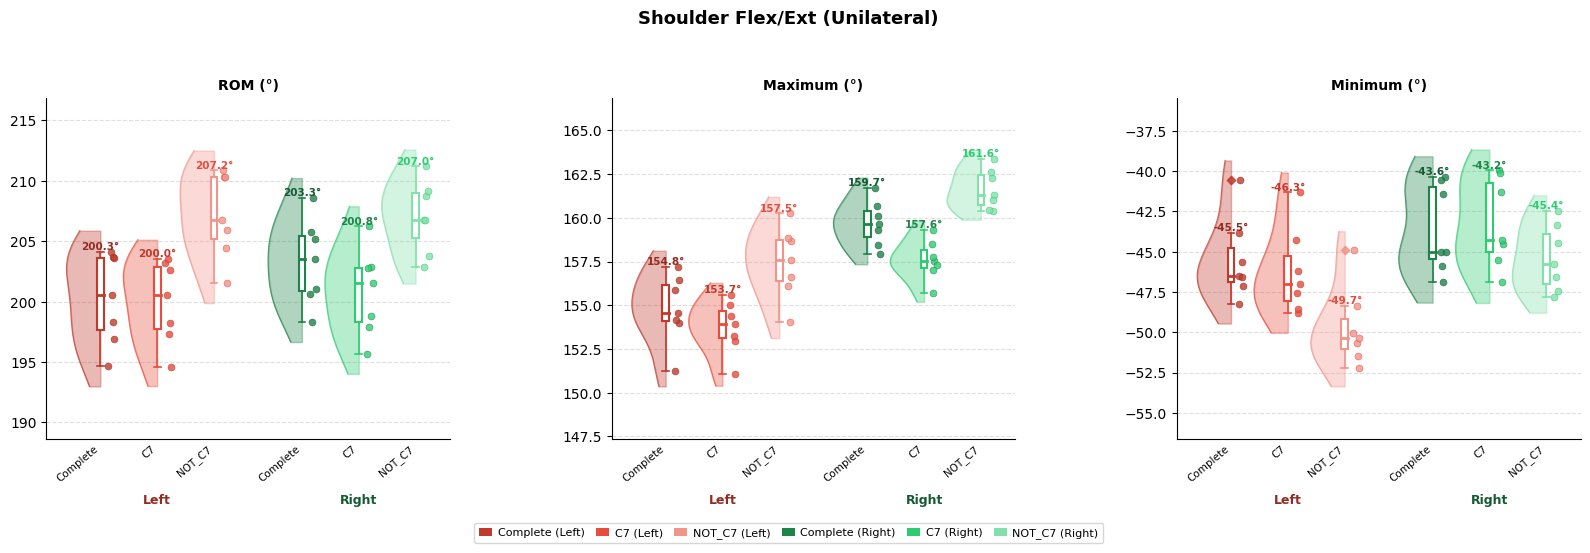


Generando: Shoulder Abd/Add (Unilateral)


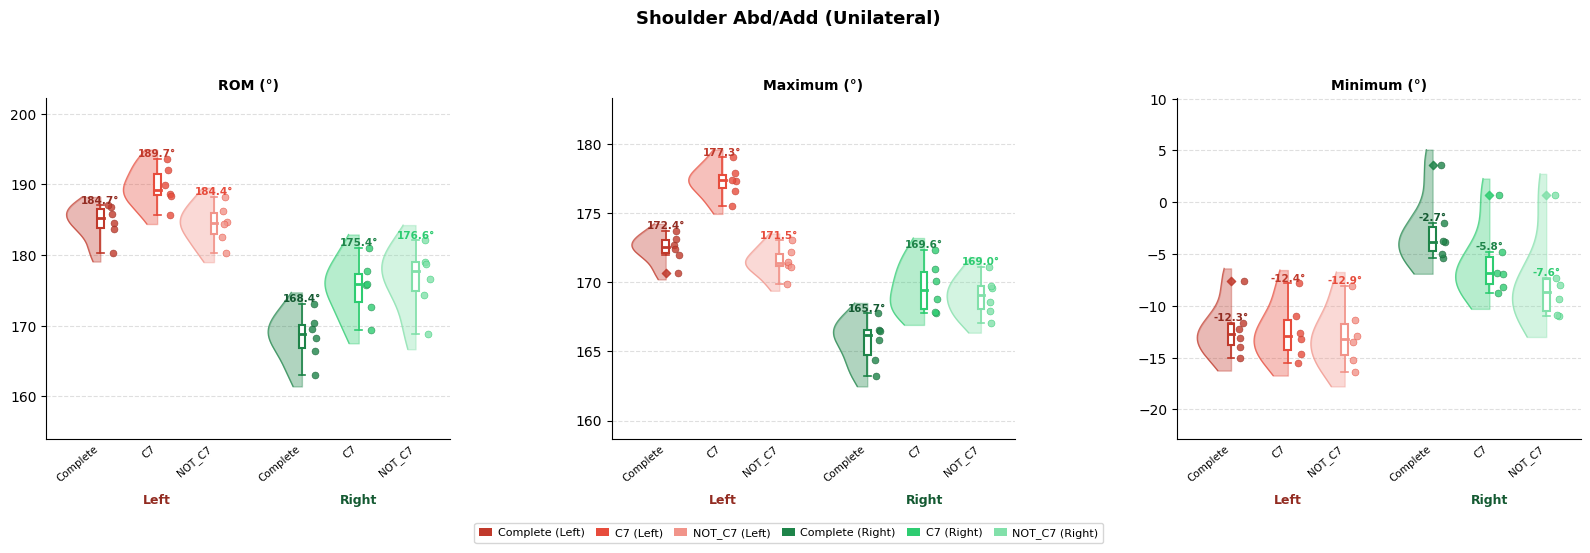


Generando: Shoulder Int/Ext Rot (Unilateral)


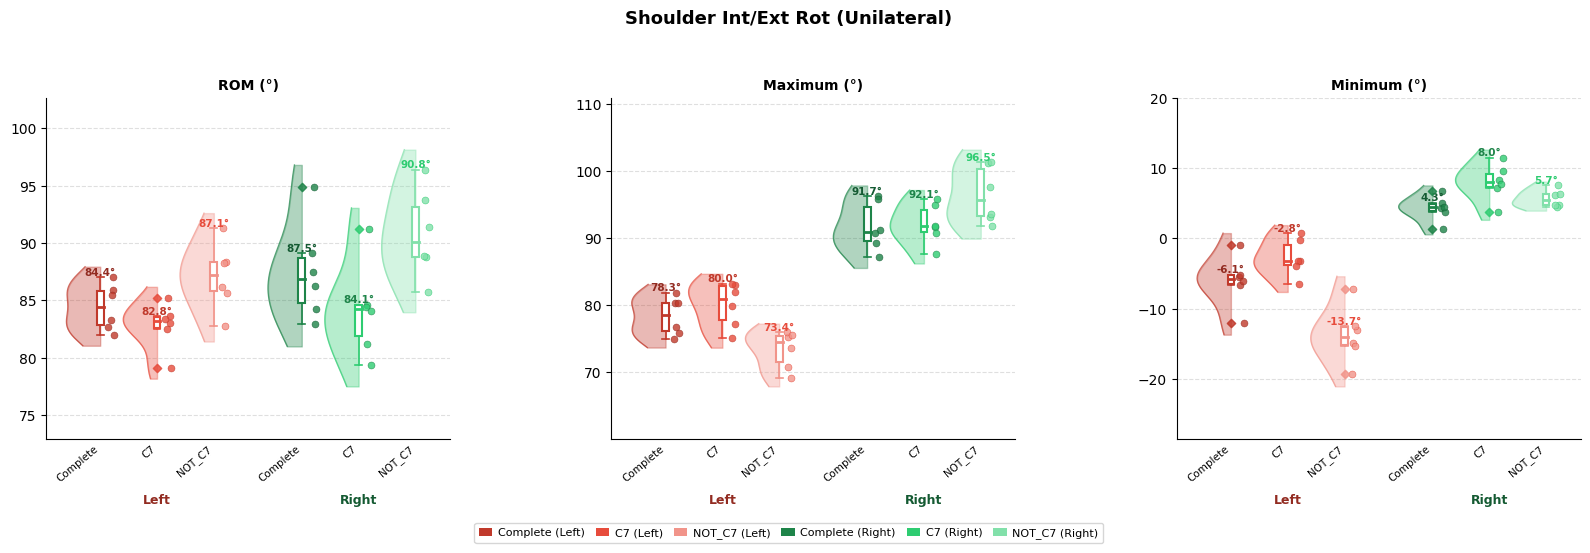


Generando: Elbow Flex/Ext (Unilateral)


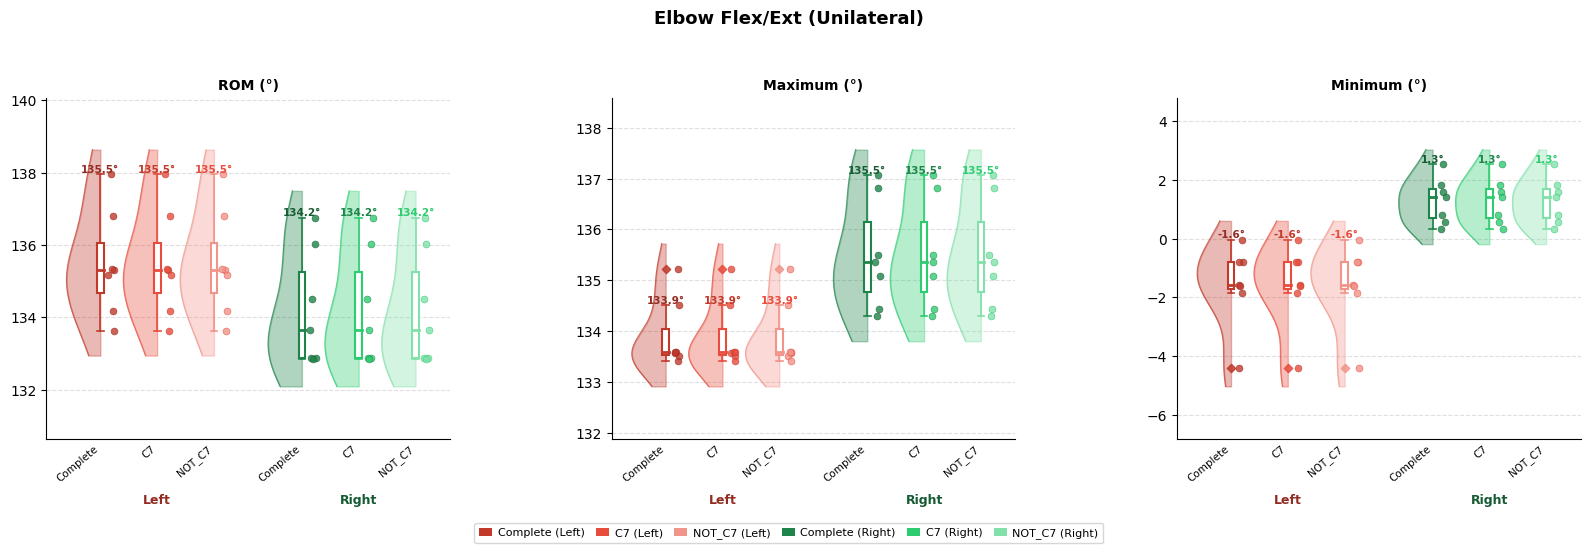


Generando: Trunk Extended Lateral Inclination (Bilateral)


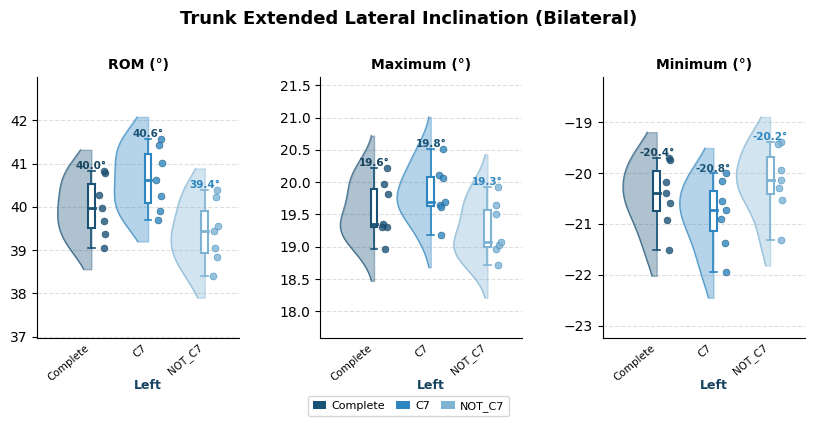


Generando: Thorax Lateral Inclination (Bilateral)


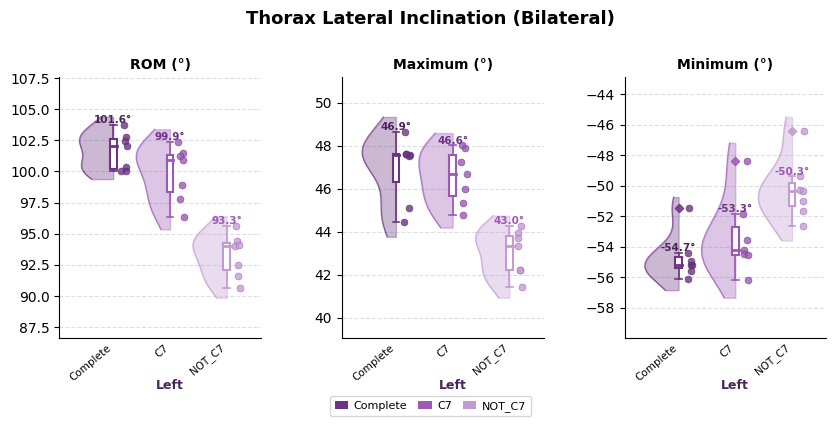

In [7]:
for movement in sections:
    print(f"\nGenerando: {movement}")
    try:
        fig = plot_movement(movement)
        plt.show()
    except Exception as e:
        print(f"  ERROR: {e}")

## 6. Diferencias entre pares de modelos (ΔROM)

In [8]:
PAIRS        = [("Complete", "C7"), ("Complete", "NOT_C7"), ("C7", "NOT_C7")]
PAIR_LABELS  = ["Complete − C7", "Complete − NOT_C7", "C7 − NOT_C7"]
PAIR_COLORS  = ["#2E86C1", "#E74C3C", "#8E44AD"]


def compute_delta_rom(movement_name: str) -> pd.DataFrame:
    """
    Calcula ΔROM max y ΔROM min entre los 3 pares de modelos,
    para cada lado disponible.
    Las diferencias se calculan rep a rep (emparejadas) y se reporta
    media ± SD entre repeticiones.
    """
    data  = extract_data(sections[movement_name])
    sides = [s for s in ["Left", "Right"] if s in next(iter(data.values()))]
    rows  = []

    for side in sides:
        for (m1, m2), label in zip(PAIRS, PAIR_LABELS):
            peaks_m1   = np.array(data[m1][side]["peak"])
            peaks_m2   = np.array(data[m2][side]["peak"])
            valleys_m1 = np.array(data[m1][side]["valley"])
            valleys_m2 = np.array(data[m2][side]["valley"])

            n = min(len(peaks_m1), len(peaks_m2))
            delta_peak   = peaks_m1[:n]   - peaks_m2[:n]
            delta_valley = valleys_m1[:n] - valleys_m2[:n]

            rows.append({
                "Movement":          movement_name,
                "Side":              side,
                "Pair":              label,
                "ΔROM max mean (°)": round(float(np.mean(delta_peak)),   2),
                "ΔROM max SD (°)":   round(float(np.std(delta_peak,   ddof=1)), 2),
                "ΔROM min mean (°)": round(float(np.mean(delta_valley)), 2),
                "ΔROM min SD (°)":   round(float(np.std(delta_valley, ddof=1)), 2),
                "n":                 n,
            })

    return pd.DataFrame(rows)


def plot_delta_rom(movement_name: str) -> plt.Figure:
    """
    Dot plot con error bars (media ± SD) de ΔROM max y ΔROM min
    para los 3 pares de modelos.
    """
    df    = compute_delta_rom(movement_name)
    sides = df["Side"].unique().tolist()

    fig, axes = plt.subplots(1, 2, figsize=(7 + 2 * len(sides), 4.5))
    fig.suptitle(f"{movement_name} — ΔROM between model pairs",
                 fontsize=12, fontweight="bold")
    fig.subplots_adjust(wspace=0.45, top=0.83, bottom=0.22)

    metrics = [
        ("ΔROM max mean (°)", "ΔROM max SD (°)", "ΔROM Maximum (°)"),
        ("ΔROM min mean (°)", "ΔROM min SD (°)", "ΔROM Minimum (°)"),
    ]

    x_gap    = 1.0
    offsets  = np.linspace(-0.28, 0.28, len(PAIR_LABELS))

    for ax, (mean_col, sd_col, title) in zip(axes, metrics):
        ax.axhline(0, color="gray", lw=0.9, linestyle="--", alpha=0.55, zorder=1)
        ax.set_title(title, fontsize=10, fontweight="bold")

        x_centers = []
        x_labels  = []

        for s_idx, side in enumerate(sides):
            x_c  = s_idx * x_gap * (len(PAIR_LABELS) + 0.5)
            sub  = df[df["Side"] == side]

            for p_idx, (pair_label, color) in enumerate(zip(PAIR_LABELS, PAIR_COLORS)):
                row = sub[sub["Pair"] == pair_label]
                if row.empty:
                    continue
                x        = x_c + offsets[p_idx]
                mean_val = row[mean_col].values[0]
                sd_val   = row[sd_col].values[0]

                ax.errorbar(x, mean_val, yerr=sd_val,
                            fmt="o", color=color, markersize=7,
                            capsize=4, capthick=1.2, elinewidth=1.2, zorder=4)
                ax.text(x, mean_val + sd_val,
                        f"{mean_val:+.2f}°",
                        ha="center", va="bottom", fontsize=7.5,
                        color=color, zorder=5)

            x_centers.append(x_c)
            x_labels.append(side)

        ax.set_xticks(x_centers)
        ax.set_xticklabels(x_labels, fontsize=9, fontweight="bold")
        ax.set_ylabel("Difference (°)", fontsize=8)
        ax.tick_params(axis="x", length=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)

    handles = [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=c, markersize=8, label=l)
        for l, c in zip(PAIR_LABELS, PAIR_COLORS)
    ]
    fig.legend(handles=handles, fontsize=8, ncol=3,
               loc="lower center", bbox_to_anchor=(0.5, 0.0),
               frameon=True, handletextpad=0.4, columnspacing=1.2,
               borderpad=0.4)

    return fig


────────────────────────────────────────────────────────────
  Shoulder Flex/Ext (Unilateral)
────────────────────────────────────────────────────────────
 Side              Pair  ΔROM max mean (°)  ΔROM max SD (°)  ΔROM min mean (°)  ΔROM min SD (°)  n
 Left     Complete − C7               1.05             0.52               0.75             0.34  7
 Left Complete − NOT_C7              -2.67             0.36               4.21             0.39  7
 Left       C7 − NOT_C7              -3.71             0.60               3.46             0.50  7
Right     Complete − C7               2.11             0.32              -0.37             0.26  7
Right Complete − NOT_C7              -1.94             0.80               1.81             0.88  7
Right       C7 − NOT_C7              -4.05             0.67               2.18             0.89  7


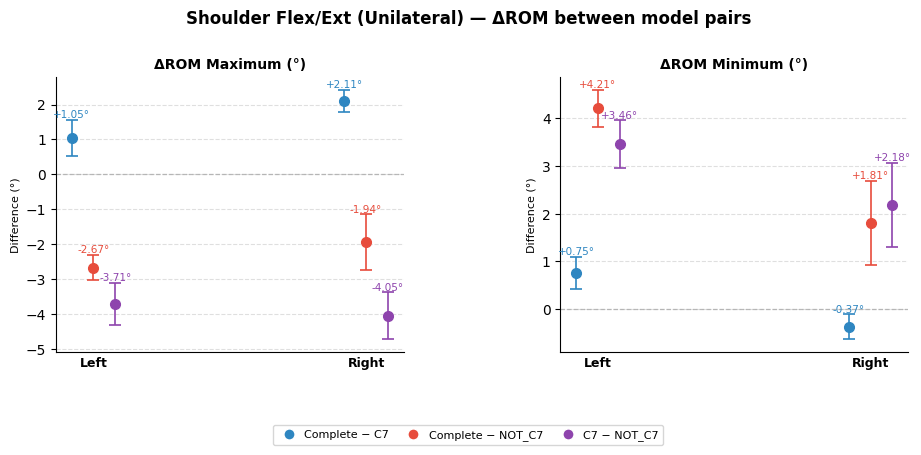


────────────────────────────────────────────────────────────
  Shoulder Abd/Add (Unilateral)
────────────────────────────────────────────────────────────
 Side              Pair  ΔROM max mean (°)  ΔROM max SD (°)  ΔROM min mean (°)  ΔROM min SD (°)  n
 Left     Complete − C7              -4.85             1.56               0.18             0.44  6
 Left Complete − NOT_C7               0.95             0.80               0.66             0.60  6
 Left       C7 − NOT_C7               5.80             0.86               0.48             0.27  6
Right     Complete − C7              -3.92             0.69               3.05             0.22  6
Right Complete − NOT_C7              -3.28             0.93               4.89             1.19  6
Right       C7 − NOT_C7               0.64             1.13               1.84             1.06  6


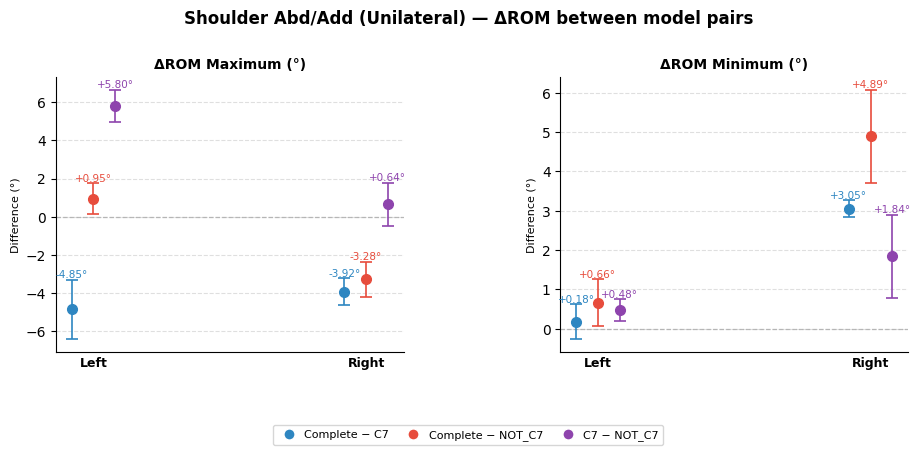


────────────────────────────────────────────────────────────
  Shoulder Int/Ext Rot (Unilateral)
────────────────────────────────────────────────────────────
 Side              Pair  ΔROM max mean (°)  ΔROM max SD (°)  ΔROM min mean (°)  ΔROM min SD (°)  n
 Left     Complete − C7              -1.70             1.36              -3.30             1.75  6
 Left Complete − NOT_C7               4.98             1.51               7.67             1.42  6
 Left       C7 − NOT_C7               6.68             2.73              10.96             2.17  6
Right     Complete − C7              -0.37             0.93              -3.71             0.85  6
Right Complete − NOT_C7              -4.73             1.27              -1.39             1.50  6
Right       C7 − NOT_C7              -4.36             1.86               2.32             2.18  6


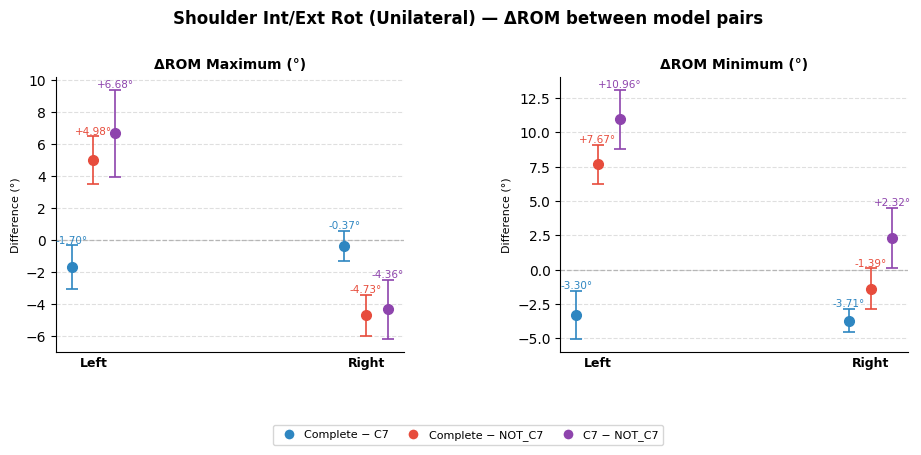


────────────────────────────────────────────────────────────
  Elbow Flex/Ext (Unilateral)
────────────────────────────────────────────────────────────
 Side              Pair  ΔROM max mean (°)  ΔROM max SD (°)  ΔROM min mean (°)  ΔROM min SD (°)  n
 Left     Complete − C7                0.0              0.0                0.0              0.0  7
 Left Complete − NOT_C7                0.0              0.0                0.0              0.0  7
 Left       C7 − NOT_C7                0.0              0.0                0.0              0.0  7
Right     Complete − C7                0.0              0.0                0.0              0.0  7
Right Complete − NOT_C7                0.0              0.0                0.0              0.0  7
Right       C7 − NOT_C7                0.0              0.0                0.0              0.0  7


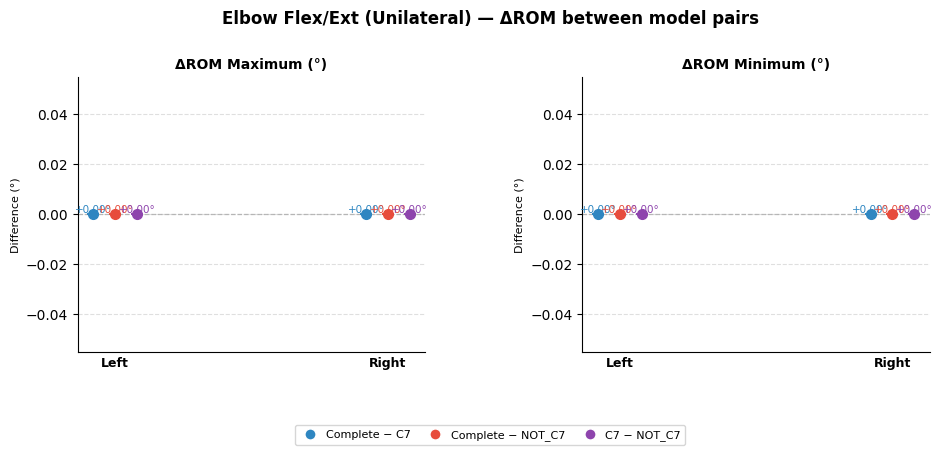


────────────────────────────────────────────────────────────
  Trunk Extended Lateral Inclination (Bilateral)
────────────────────────────────────────────────────────────
Side              Pair  ΔROM max mean (°)  ΔROM max SD (°)  ΔROM min mean (°)  ΔROM min SD (°)  n
Left     Complete − C7              -0.27             0.08               0.38             0.07  7
Left Complete − NOT_C7               0.30             0.04              -0.28             0.06  7
Left       C7 − NOT_C7               0.57             0.09              -0.66             0.10  7


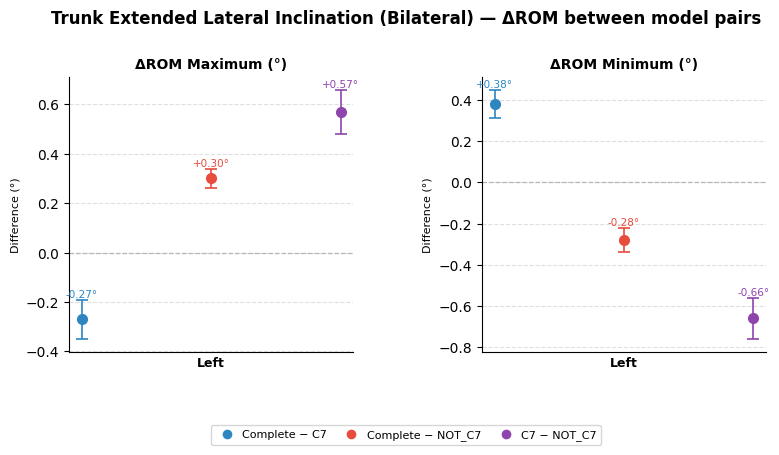


────────────────────────────────────────────────────────────
  Thorax Lateral Inclination (Bilateral)
────────────────────────────────────────────────────────────
Side              Pair  ΔROM max mean (°)  ΔROM max SD (°)  ΔROM min mean (°)  ΔROM min SD (°)  n
Left     Complete − C7               0.37             1.04              -1.40             1.42  7
Left Complete − NOT_C7               3.92             0.87              -4.46             0.89  7
Left       C7 − NOT_C7               3.55             0.39              -3.05             0.75  7


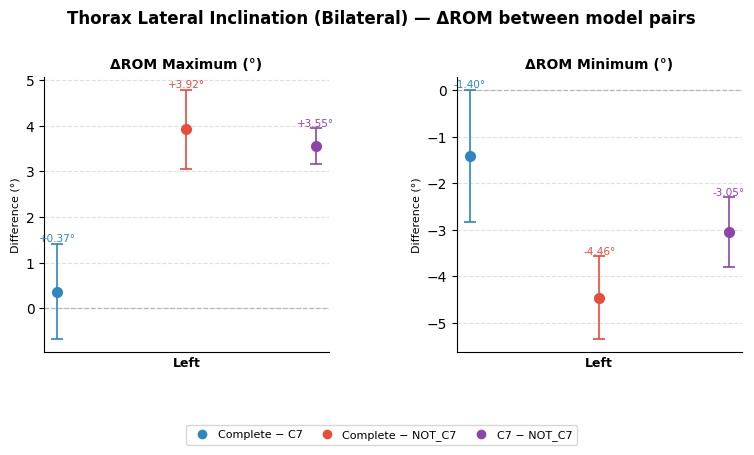



=== RESUMEN GLOBAL ===
                                      Movement  Side              Pair  ΔROM max mean (°)  ΔROM max SD (°)  ΔROM min mean (°)  ΔROM min SD (°)  n
                Shoulder Flex/Ext (Unilateral)  Left     Complete − C7               1.05             0.52               0.75             0.34  7
                Shoulder Flex/Ext (Unilateral)  Left Complete − NOT_C7              -2.67             0.36               4.21             0.39  7
                Shoulder Flex/Ext (Unilateral)  Left       C7 − NOT_C7              -3.71             0.60               3.46             0.50  7
                Shoulder Flex/Ext (Unilateral) Right     Complete − C7               2.11             0.32              -0.37             0.26  7
                Shoulder Flex/Ext (Unilateral) Right Complete − NOT_C7              -1.94             0.80               1.81             0.88  7
                Shoulder Flex/Ext (Unilateral) Right       C7 − NOT_C7              -4.05          

In [9]:
# Tabla resumen + gráfica de ΔROM para todos los movimientos
all_deltas = []

for movement in sections:
    print(f"\n{'─'*60}")
    print(f"  {movement}")
    print(f"{'─'*60}")

    df_delta = compute_delta_rom(movement)
    all_deltas.append(df_delta)

    display_cols = ["Side", "Pair", "ΔROM max mean (°)", "ΔROM max SD (°)",
                    "ΔROM min mean (°)", "ΔROM min SD (°)", "n"]
    print(df_delta[display_cols].to_string(index=False))

    fig = plot_delta_rom(movement)
    plt.show()

df_all_deltas = pd.concat(all_deltas, ignore_index=True)
print("\n\n=== RESUMEN GLOBAL ===")
print(df_all_deltas.to_string(index=False))